# Baseline Catboost Model

In [ ]:
%%capture
! pip install catboost

In [ ]:
import pandas as pd, numpy as np, \
seaborn as sns, matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

merged = pd.read_csv('merged.csv', index_col = 0)
merged.head()

,player_id,name_x,position_x,team_x,season_x,conference,usage_passing_downs,usage_standard_downs,usage_third_down,usage_second_down,usage_first_down,usage_rush,usage_var_pass,usage_overall,avg_ppa_passing_downs,avg_ppa_standard_downs,avg_ppa_third_down,avg_ppa_second_down,avg_ppa_first_down,avg_ppa_rush,avg_ppa_var_pass,avg_ppa_all,total_ppa_passing_downs,total_ppa_standard_downs,total_ppa_third_down,total_ppa_second_down,total_ppa_first_down,total_ppa_rush,total_ppa_var_pass,total_ppa_all,fumbles_FUM,fumbles_LOST,fumbles_REC,passing_ATT,passing_COMPLETIONS,passing_INT,passing_PCT,passing_TD,passing_YDS,passing_YPA,receiving_LONG,receiving_REC,receiving_TD,receiving_YDS,receiving_YPR,rushing_ATT,rushing_LONG,rushing_TD,rushing_YDS,rushing_YPC,college_athlete_id,nfl_athlete_id,college_id,college_team,college_conference,nfl_team_id,nfl_team,position_y,name_y,year,round_x,pick_number,overall,height_in,weight_lbs,pre_draft_position_ranking,pre_draft_grade,pfr_player_id,cfb_player_id,season_y,round_y,pick,team_y,pfr_player_name,position,category,college,w_av,car_av,dr_av,ht,wt,forty,bench,vertical,broad_jump,cone,shuttle,pfr_id,birth_date,height,weight,rookie_season,last_season,birth_year,age
0,100009,Johnny Jackson,WR,Arizona,2015,PAC,0.104000,0.049000,0.094000,0.065000,0.055000,0.000000,0.133000,0.065000,0.953000,0.413000,1.314000,0.839000,0.415000,NaN,0.674,0.6740,28.600000,13.214000,22.345000,16.772000,9.542000,0.000000,41.813000,41.813000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.0,50.0,5.0,612.0,12.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,102597,Will Rogers,QB,Washington,2024,B1G,0.670000,0.458333,0.652167,0.532667,0.454333,0.060167,0.888000,0.520333,0.443833,0.188333,0.426833,0.438667,0.138167,-0.1675,0.313,0.2910,57.095833,43.996000,36.587833,45.864333,24.582667,-3.056667,104.148667,101.092333,4.5,2.166667,0.5,336.166667,226.333333,6.166667,0.666333,16.833333,2431.5,7.333333,NaN,NaN,NaN,NaN,NaN,34.000000,17.500000,0.333333,-71.333333,-1.916667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,107494,Trey Sanders,RB,TCU,2024,B12,0.043400,0.068400,0.047267,0.071533,0.058267,0.119733,0.008867,0.060600,0.646133,0.010467,0.280800,-0.090933,-0.006867,0.1442,NaN,0.1604,2.071933,2.040267,3.381200,-0.835133,-0.067467,3.438600,0.674133,4.112733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.466667,15.333333,2.066667,128.733333,4.173333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,109907,Jon Lee,RB,Air Force,2014,MWC,0.035000,0.025000,0.015000,0.057000,0.015000,0.023000,0.052000,0.028000,0.630000,-0.128000,-0.363000,0.173000,0.222000,0.1790,0.015,0.1240,1.890000,-0.770000,-0.363000,1.040000,0.444000,1.076000,0.044000,1.120000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,2.0,0.0,12.0,6.0,6.000000,32.000000,0.000000,39.000000,6.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,136429,Cedric Patterson III,WR,Rice,2022,CUSA,0.077333,0.033667,0.116667,0.018000,0.045000,0.022667,0.086667,0.050667,0.224000,0.066333,0.166000,NaN,0.191333,0.1360,0.150,0.1760,6.349333,6.364667,3.909000,2.029667,6.775333,0.465333,12.248333,12.714000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.666667,15.333333,0.333333,16.000000,7.100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
merged.columns

Index(['player_id', 'name_x', 'position_x', 'team_x', 'season_x', 'conference',
       'usage_passing_downs', 'usage_standard_downs', 'usage_third_down',
       'usage_second_down', 'usage_first_down', 'usage_rush', 'usage_var_pass',
       'usage_overall', 'avg_ppa_passing_downs', 'avg_ppa_standard_downs',
       'avg_ppa_third_down', 'avg_ppa_second_down', 'avg_ppa_first_down',
       'avg_ppa_rush', 'avg_ppa_var_pass', 'avg_ppa_all',
       'total_ppa_passing_downs', 'total_ppa_standard_downs',
       'total_ppa_third_down', 'total_ppa_second_down', 'total_ppa_first_down',
       'total_ppa_rush', 'total_ppa_var_pass', 'total_ppa_all', 'fumbles_FUM',
       'fumbles_LOST', 'fumbles_REC', 'passing_ATT', 'passing_COMPLETIONS',
       'passing_INT', 'passing_PCT', 'passing_TD', 'passing_YDS',
       'passing_YPA', 'receiving_LONG', 'receiving_REC', 'receiving_TD',
       'receiving_YDS', 'receiving_YPR', 'rushing_ATT', 'rushing_LONG',
       'rushing_TD', 'rushing_YDS', 'rushing_YPC', 

In [ ]:
# filling in NAs for counting stats (they should all be zero)
merged.fillna(value={
    'fumbles_FUM' : 0,
    'fumbles_LOST' : 0,
    'fumbles_REC' : 0,
    'passing_ATT': 0,
    'passing_COMPLETIONS' : 0,
    'passing_PCT' : 0,
    'passing_INT' : 0,
    'passing_TD' : 0,
    'passing_YDS' : 0,
    'passing_YPA' : 0,
    'receiving_LONG' : 0,
    'receiving_REC' : 0,
    'receiving_TD' : 0,
    'receiving_YDS' : 0,
    'receiving_YPR' : 0,
    'rushing_ATT' : 0,
    'rushing_LONG' : 0,
    'rushing_TD' : 0,
    'rushing_YDS' : 0,
    'rushing_YPC' : 0
},
              inplace=True)

merged.dropna(axis = 0, subset = 'overall', inplace=True)

merged['INT_pct'] = merged['passing_INT']/merged['passing_ATT']

merged.fillna(value={'INT_pct' : 0}, inplace=True)

# Taking yearly average of wAV so players drafted earlier don't have higher values
# since wAV is a cumulative stat
# (in other words, I'm turning it into a rate stat)
merged['adjusted_w_av'] = (merged['w_av']/
 ((merged['last_season'] + 1) - merged['year'])
)

X = merged[['position_x', 'usage_overall', 'avg_ppa_all', 'total_ppa_all','conference',
            'fumbles_FUM', 'fumbles_LOST', 'passing_ATT', 'passing_COMPLETIONS',
            'passing_PCT', 'INT_pct','passing_TD', 'passing_YDS','passing_YPA', 'receiving_REC',
            'receiving_TD', 'receiving_YDS', 'receiving_YPR', 'rushing_ATT', 'rushing_TD',
            'rushing_YDS', 'rushing_YPC', 'age', 'height', 'weight']]

y = merged['adjusted_w_av'].fillna(value=0)


X

,position_x,usage_overall,avg_ppa_all,total_ppa_all,conference,fumbles_FUM,fumbles_LOST,passing_ATT,passing_COMPLETIONS,passing_PCT,INT_pct,passing_TD,passing_YDS,passing_YPA,receiving_REC,receiving_TD,receiving_YDS,receiving_YPR,rushing_ATT,rushing_TD,rushing_YDS,rushing_YPC,age,height,weight
10,WR,0.114400,0.792400,79.568000,B1G,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,66.200000,10.300000,1027.400000,15.490000,0.000000,0.000000,0.000000,0.000000,22.0,73.0,208.0
13,WR,0.026000,-0.166000,-1.163000,SEC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,1.000000,0.000000,-3.000000,-3.000000,2.000000,0.000000,30.000000,15.000000,25.0,72.0,190.0
15,QB,0.475000,0.341000,173.161000,B12,0.000000,0.000000,428.0,270.0,0.631,0.016355,29.0,3855.0,9.00,0.000000,0.000000,0.000000,0.000000,84.000000,6.000000,101.000000,1.200000,24.0,75.0,226.0
37,TE,0.036000,0.481000,12.016000,PAC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,21.000000,2.000000,197.000000,9.400000,0.000000,0.000000,0.000000,0.000000,23.0,76.0,250.0
45,QB,0.524000,0.098000,44.653000,B1G,0.000000,0.000000,392.0,228.0,0.582,0.028061,7.0,2214.0,5.60,1.000000,1.000000,17.000000,17.000000,68.000000,5.000000,-123.000000,-1.800000,24.0,75.0,220.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10096,RB,0.266167,0.161167,33.282500,ACC,1.666667,0.833333,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,47.500000,2.500000,354.000000,7.133333,202.166667,11.166667,910.500000,4.833333,21.0,72.0,201.0
10554,RB,0.214000,0.273500,50.862000,SEC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,16.166667,0.333333,133.833333,8.366667,174.000000,14.333333,1012.666667,5.933333,21.0,68.0,201.0
10645,WR,0.100667,1.259333,68.872667,MWC,0.000000,0.000000,0.0,0.0,0.000,0.000000,0.0,0.0,0.00,60.333333,9.000000,916.000000,15.200000,0.000000,0.000000,0.000000,0.000000,22.0,72.0,195.0
10661,TE,0.127500,0.784167,77.936500,MAC,0.000000,0.000000,1.5,0.5,0.250,0.000000,0.0,4.5,2.25,76.333333,7.166667,1019.000000,13.250000,10.833333,1.166667,55.000000,5.450000,21.0,76.0,241.0


In [ ]:
X.isna().sum()

,0
position_x,0
usage_overall,0
avg_ppa_all,0
total_ppa_all,0
conference,0
fumbles_FUM,0
fumbles_LOST,0
passing_ATT,0
passing_COMPLETIONS,0
passing_PCT,0


In [ ]:
na_idx = X[X.isna().any(axis=1)].index
print(na_idx)

X_nona = X.drop(index=na_idx, inplace = False)
y_nona = y.drop(index=na_idx, inplace=False)

Index([114, 229, 4314, 7510], dtype='int64')


In [ ]:
y_nona

,adjusted_w_av
10,1.500000
13,0.000000
15,1.000000
37,0.000000
45,1.454545
...,...
10096,1.000000
10554,3.000000
10645,0.000000
10661,5.000000


In [ ]:
# checking for NA valuesi n y_nona
y_nona.isna().sum()

np.int64(0)

In [ ]:
y_nona.value_counts()

,count
adjusted_w_av,
0.000000,175
1.000000,49
0.500000,39
2.000000,36
3.000000,23
...,...
10.333333,1
13.333333,1
7.750000,1


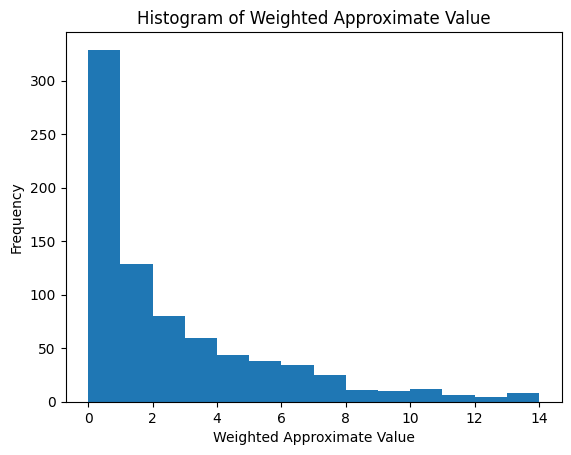

In [ ]:
bin_width = 1

bins = np.arange(min(y_nona), max(y_nona) + bin_width, bin_width)

plt.hist(y_nona, bins = bins)
plt.ylabel('Frequency')
plt.xlabel('Weighted Approximate Value')
plt.title('Histogram of Weighted Approximate Value')
plt.show()

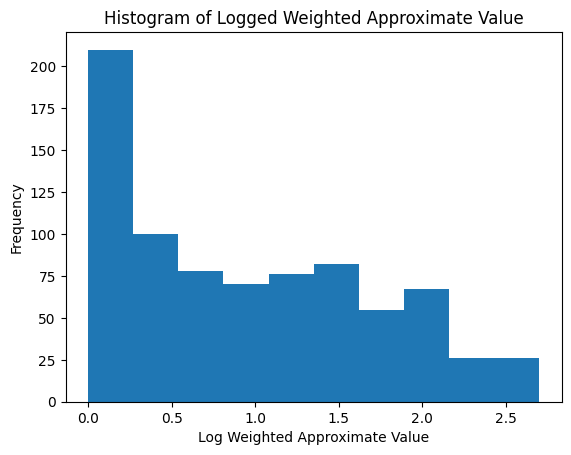

In [ ]:
y_log = y_nona.copy()
y_log = np.log(y_log + 1)

plt.hist(y_log)
plt.ylabel('Frequency')
plt.xlabel('Log Weighted Approximate Value')
plt.title('Histogram of Logged Weighted Approximate Value')
plt.show()

In [ ]:
y_log.value_counts()

,count
adjusted_w_av,
0.000000,175
0.693147,49
0.405465,39
1.098612,36
1.386294,23
...,...
2.427748,1
2.662588,1
2.169054,1


In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split


train_x, test_x, train_y, test_y = train_test_split(X_nona,
                                                    y_nona,
                                                    test_size = 0.3,
                                                    random_state = 42)

# num_cols = train_x.select_dtypes(include=np.number).columns
# cat_cols = train_x.select_dtypes(include=['str', 'category']).columns


# # Create transformer
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), num_cols)
#     ],
#     remainder='passthrough',
#     verbose_feature_names_out=False
# )

# preprocessor.set_output(transform="pandas")

# # Fit on training data, transform both
# train_x = preprocessor.fit_transform(train_x)
# test_x = preprocessor.transform(test_x)

In [ ]:
train_x

,position_x,usage_overall,avg_ppa_all,total_ppa_all,conference,fumbles_FUM,fumbles_LOST,passing_ATT,passing_COMPLETIONS,passing_PCT,INT_pct,passing_TD,passing_YDS,passing_YPA,receiving_REC,receiving_TD,receiving_YDS,receiving_YPR,rushing_ATT,rushing_TD,rushing_YDS,rushing_YPC,age,height,weight
6816,WR,0.061600,0.697200,30.649700,SEC,0.0,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.0,33.600000,3.600000,541.600000,15.700000,0.000000,0.000000,0.000000,0.000000,22.0,74.0,225.0
4966,WR,0.084700,0.517900,31.720400,B1G,0.0,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.0,29.600000,3.900000,440.100000,14.380000,8.600000,1.300000,72.300000,8.190000,22.0,73.0,185.0
328,QB,0.545000,0.305000,157.795000,PAC,0.0,0.0,392.0,271.0,0.691,0.012755,22.0,3155.0,8.0,1.000000,0.000000,9.000000,9.000000,159.000000,10.000000,644.000000,4.100000,22.0,75.0,226.0
1672,TE,0.050333,0.838500,47.072000,ACC,0.0,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.0,38.666667,6.333333,569.833333,14.283333,0.000000,0.000000,0.000000,0.000000,22.0,77.0,258.0
3345,TE,0.089500,0.581000,31.880500,MAC,0.0,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.0,32.500000,4.500000,454.500000,14.266667,0.000000,0.000000,0.000000,0.000000,23.0,75.0,248.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
893,WR,0.062333,0.615667,35.769333,B12,0.0,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.0,33.666667,4.666667,649.000000,19.400000,1.333333,0.000000,13.666667,10.500000,22.0,73.0,183.0
1345,WR,0.182000,0.503000,79.631000,MAC,0.0,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.0,102.333333,5.666667,1306.333333,12.966667,1.666667,0.000000,2.666667,-0.433333,22.0,76.0,194.0
3290,RB,0.163000,0.170857,25.945143,SEC,0.0,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.0,7.000000,0.000000,54.714286,6.600000,130.857143,4.714286,723.285714,5.557143,24.0,71.0,210.0
5077,RB,0.182300,0.252000,29.397600,B1G,0.0,0.0,0.0,0.0,0.000,0.000000,0.0,0.0,0.0,11.200000,0.500000,108.600000,9.660000,107.500000,5.900000,727.300000,6.900000,22.0,72.0,215.0


In [ ]:
pd.Series(train_y).describe()

,adjusted_w_av
count,553.000000
mean,2.474309
std,2.943577
min,0.000000
25%,0.250000
50%,1.333333
75%,3.750000
max,13.875000


In [ ]:
import numpy as np

class GammaObjective(object):
    def calc_ders_range(self, approxes, targets, weights):
        # Numba loves simple, explicit loops. It will compile this to C-speed.
        result = []

        for i in range(len(targets)):
            # 1. Get the raw prediction and clip it manually
            # (Numba handles basic if/else much better than np.clip)
            approx = approxes[i]
            if approx > 20.0:
                approx = 20.0
            elif approx < -20.0:
                approx = -20.0

            # Apply log-link
            mu = np.exp(approx)

            # 2. Calculate derivatives
            der1 = (targets[i] / mu) - 1.0
            der2 = -(targets[i] / mu)

            # 3. Apply weights if they exist
            if weights is not None:
                der1 *= weights[i]
                der2 *= weights[i]

            # 4. Append as a tuple
            result.append((der1, der2))

        return result

class GammaRMSEMetric(object):
    def get_final_error(self, error, weight):
        # The evaluate method returns the Sum of Squared Errors.
        # Here, we divide by the total weight (or count) and take the square root.
        return np.sqrt(error / (weight + 1e-38))

    def is_max_optimal(self):
        # We are minimizing RMSE, so max is not optimal
        return False

    def evaluate(self, approxes, targets, weights):
        # Numba-friendly loop for evaluation
        approx = approxes[0]

        error_sum = 0.0
        weight_sum = 0.0

        for i in range(len(targets)):
            # 1. Get raw prediction and clip to prevent np.exp() overflow
            z = approx[i]
            if z > 20.0:
                z = 20.0
            elif z < -20.0:
                z = -20.0

            # 2. Transform back to original scale (The expected value)
            mu = np.exp(z)

            # 3. Calculate the Squared Error: (y - mu)^2
            sq_error = (targets[i] - mu) ** 2

            # 4. Accumulate sums
            if weights is not None:
                w = weights[i]
                error_sum += sq_error * w
                weight_sum += w
            else:
                error_sum += sq_error
                weight_sum += 1.0

        # Return the total Sum of Squared Errors and the total weight
        return error_sum, weight_sum

In [ ]:
from catboost import CatBoostRegressor

# finds categorical features
cat_features = train_x.select_dtypes(include=['object', 'category']).columns
cat_indices = [train_x.columns.get_loc(col) for col in cat_features]

model = CatBoostRegressor(
    iterations=2000,
    depth=3,
    learning_rate=0.05,
    loss_function=GammaObjective(),
    eval_metric = GammaRMSEMetric(),
    l2_leaf_reg = 10,
    verbose=100,
    random_state = 42
)

model.fit(
    train_x,
    (train_y),
    eval_set = (test_x, test_y),
    cat_features=cat_indices # assigns categorical features
)

preds = model.predict(test_x)

0:	learn: 3.2765447	test: 3.2586349	best: 3.2586349 (0)	total: 1.7s	remaining: 56m 46s
100:	learn: 2.5675699	test: 2.7028179	best: 2.7028179 (100)	total: 1.94s	remaining: 36.6s
200:	learn: 2.3488105	test: 2.6121825	best: 2.6092536 (195)	total: 2.19s	remaining: 19.6s
300:	learn: 2.2445707	test: 2.6238685	best: 2.6092536 (195)	total: 2.41s	remaining: 13.6s
400:	learn: 2.1687552	test: 2.6167462	best: 2.6092536 (195)	total: 2.63s	remaining: 10.5s
500:	learn: 2.1048826	test: 2.6090634	best: 2.6090634 (500)	total: 2.86s	remaining: 8.57s
600:	learn: 2.0583704	test: 2.6342321	best: 2.6090634 (500)	total: 3.09s	remaining: 7.19s
700:	learn: 2.0221788	test: 2.6355090	best: 2.6090634 (500)	total: 3.33s	remaining: 6.18s
800:	learn: 1.9927494	test: 2.6437373	best: 2.6090634 (500)	total: 3.56s	remaining: 5.32s
900:	learn: 1.9713093	test: 2.6474381	best: 2.6090634 (500)	total: 3.77s	remaining: 4.6s
1000:	learn: 1.9588543	test: 2.6421669	best: 2.6090634 (500)	total: 4s	remaining: 3.99s
1100:	learn: 1.9

In [ ]:
print(f"{"="*10}Raw Predictions{"="*10}\n{pd.Series(preds).describe()}")
print(f"{"="*10}Exponentiated Predictions{"="*10}\n{pd.Series(np.exp(preds)).describe()}")

==========Raw Predictions==========
count    237.000000
mean       0.578150
std        0.667156
min       -1.387289
25%        0.188481
50%        0.620139
75%        1.041902
max        2.321646
dtype: float64
==========Exponentiated Predictions==========
count    237.000000
mean       2.195048
std        1.462568
min        0.249751
25%        1.207414
50%        1.859186
75%        2.834602
max       10.192439
dtype: float64


In [ ]:
from sklearn.metrics import root_mean_squared_error as rmse
preds_exp = np.exp(preds)
#test_y_exp = np.exp(test_y) - 1

test_rmse = rmse(test_y, preds_exp)

print(f"Test RMSE: {test_rmse:.2f}")

Test RMSE: 2.61


In [ ]:
from catboost import cv, Pool

cv_dataset = Pool(data=train_x, label=(train_y +1), cat_features=cat_indices)

params = {
    "iterations": 2000,
    "depth": 3,
    "loss_function": GammaObjective(),
    #'loss_function':'Tweedie:variance_power=1.4',
    "eval_metric": GammaRMSEMetric(),
    #'eval_metric' : "RMSE",
    "l2_leaf_reg": 10,
    "verbose": 100,
    "random_state" : 42
}

# This will run cleanly without cloning errors
cv_results = cv(
    pool=cv_dataset,
    params=params,
    fold_count=10,
    early_stopping_rounds=50,
    return_models=False
)

print(f"\nBest Test RMSE: {cv_results['test-GammaRMSEMetric-mean'].min():.4f}")

Training on fold [0/10]
0:	learn: 3.8272293	test: 3.8527536	best: 3.8527536 (0)	total: 581ms	remaining: 19m 22s
100:	learn: 2.7968938	test: 2.8602937	best: 2.8602937 (100)	total: 920ms	remaining: 17.3s
200:	learn: 2.5100198	test: 2.7068794	best: 2.7051422 (197)	total: 1.25s	remaining: 11.2s
300:	learn: 2.3622697	test: 2.6836793	best: 2.6832833 (296)	total: 1.62s	remaining: 9.14s
400:	learn: 2.2624259	test: 2.6718229	best: 2.6705239 (396)	total: 1.97s	remaining: 7.85s

bestTest = 2.670523936
bestIteration = 396

Training on fold [1/10]
0:	learn: 3.7960175	test: 4.1177462	best: 4.1177462 (0)	total: 4.8ms	remaining: 9.6s
100:	learn: 2.7789241	test: 3.1888786	best: 3.1888786 (100)	total: 298ms	remaining: 5.61s
200:	learn: 2.4810406	test: 2.9955613	best: 2.9955613 (200)	total: 553ms	remaining: 4.95s
300:	learn: 2.2999138	test: 2.9612039	best: 2.9552348 (285)	total: 787ms	remaining: 4.44s

bestTest = 2.955234761
bestIteration = 285

Training on fold [2/10]
0:	learn: 3.8776433	test: 3.3749221

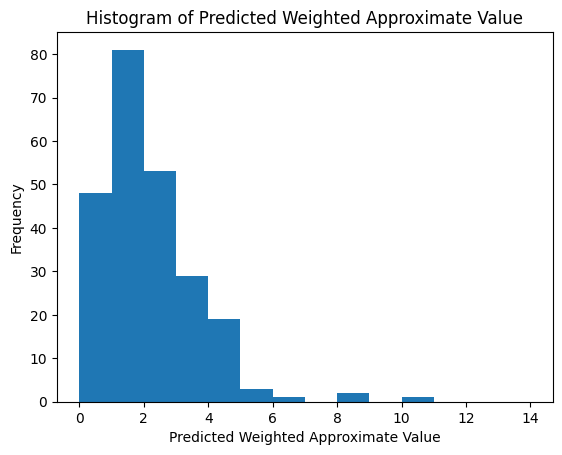

In [ ]:
plt.hist(preds_exp, bins = bins)
plt.ylabel('Frequency')
plt.xlabel('Predicted Weighted Approximate Value')
plt.title('Histogram of Predicted Weighted Approximate Value')
plt.show()

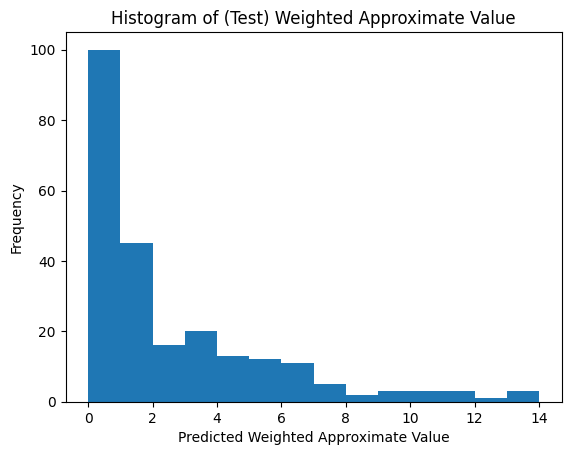

In [ ]:
plt.hist(test_y, bins = bins)
plt.ylabel('Frequency')
plt.xlabel('Predicted Weighted Approximate Value')
plt.title('Histogram of (Test) Weighted Approximate Value')
plt.show()

In [ ]:
from sklearn.model_selection import KFold
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse # Re-import rmse here to ensure it's a function

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

# Define numerical and categorical columns for the preprocessor, based on X_nona structure.
# These were implicitly identified in the previous preprocessing step (NYVxNwb6PztL).
# Ensuring they are explicitly available here for clarity and correctness.
num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include='object').columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original) # Apply StandardScaler to numerical columns
        ],
        remainder='passthrough', # Keep categorical columns as they are for CatBoost
        verbose_feature_names_out=False
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    # Identify categorical feature indices in the processed data for CatBoost
    cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category']).columns
    cat_indices_fold = [X_train_processed.columns.get_loc(col) for col in cat_features_in_processed_data]

    model = CatBoostRegressor(
        iterations=2000,
        depth=6,
        learning_rate=0.05,
        loss_function='RMSE',
        verbose=1000,
        l2_leaf_reg = 10,
        random_seed=101 # Added random_seed for reproducibility
    )

    model.fit(
        X_train_processed,
        y_train_fold,
        eval_set = (X_val_processed, y_val_fold),
        cat_features=cat_indices_fold
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

0:	learn: 0.7615862	test: 0.8176041	best: 0.8176041 (0)	total: 12.6ms	remaining: 25.1s
1000:	learn: 0.3062265	test: 0.7367422	best: 0.7231914 (173)	total: 15.8s	remaining: 15.8s
1999:	learn: 0.1839003	test: 0.7409859	best: 0.7231914 (173)	total: 30.8s	remaining: 0us

bestTest = 0.7231913745
bestIteration = 173

Shrink model to first 174 iterations.
0:	learn: 0.7641433	test: 0.8024851	best: 0.8024851 (0)	total: 5.82ms	remaining: 11.6s
1000:	learn: 0.3133638	test: 0.7354668	best: 0.7345717 (790)	total: 5.33s	remaining: 5.32s
1999:	learn: 0.1841648	test: 0.7317029	best: 0.7314573 (1794)	total: 12.3s	remaining: 0us

bestTest = 0.7314572866
bestIteration = 1794

Shrink model to first 1795 iterations.
0:	learn: 0.7684157	test: 0.7630714	best: 0.7630714 (0)	total: 6.91ms	remaining: 13.8s
1000:	learn: 0.3174315	test: 0.6941698	best: 0.6836515 (203)	total: 5.21s	remaining: 5.2s
1999:	learn: 0.1761649	test: 0.7067326	best: 0.6836515 (203)	total: 12s	remaining: 0us

bestTest = 0.6836514752
bestIt

In [ ]:
y_log.describe()

,adjusted_w_av
count,790.000000
mean,0.926980
std,0.772268
min,0.000000
25%,0.223144
50%,0.810930
75%,1.545783
max,2.699682


# NGBoost

In [ ]:
%%capture
! pip install ngboost

In [ ]:
from ngboost import NGBRegressor
from ngboost.distns import Exponential, LogNormal
from sklearn.tree import DecisionTreeRegressor

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

# Define numerical and categorical columns for the preprocessor, based on X_nona structure.
# These were implicitly identified in the previous preprocessing step (NYVxNwb6PztL).
# Ensuring they are explicitly available here for clarity and correctness.
num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include='object').columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_nona.iloc[train_idx], y_nona.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(sparse_output = False), cat_cols_original)
        ],
        remainder='passthrough', # Keep categorical columns as they are for CatBoost
        verbose_feature_names_out=False
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    model = NGBRegressor(
      n_estimators = 2000,
        Dist = LogNormal,
      learning_rate = 0.01,
      Base = DecisionTreeRegressor(max_depth = 3),
      minibatch_frac = 0.5,
      random_state = 42
    )

    model.fit(
        X_train_processed,
        (y_train_fold + 1),
        X_val = X_val_processed,
        Y_val = (y_val_fold + 1),
        early_stopping_rounds = 50
    )

    preds = model.predict(X_val_processed)

    test_rmse = rmse((y_val_fold + 1), preds)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

[iter 0] loss=2.0780 val_loss=2.1374 scale=1.0000 norm=0.8222
[iter 100] loss=1.8478 val_loss=2.0388 scale=1.0000 norm=0.7121
== Early stopping achieved.
== Best iteration / VAL123 (val_loss=2.0304)
[iter 0] loss=2.0711 val_loss=2.1620 scale=1.0000 norm=0.8151
[iter 100] loss=1.8947 val_loss=2.0896 scale=2.0000 norm=1.4313
== Early stopping achieved.
== Best iteration / VAL117 (val_loss=2.0865)
[iter 0] loss=2.0788 val_loss=2.1343 scale=1.0000 norm=0.8195
[iter 100] loss=1.8593 val_loss=2.0498 scale=1.0000 norm=0.6969
== Early stopping achieved.
== Best iteration / VAL132 (val_loss=2.0380)
[iter 0] loss=2.0680 val_loss=1.9384 scale=1.0000 norm=0.8187
[iter 100] loss=1.8697 val_loss=1.8955 scale=1.0000 norm=0.7137
== Early stopping achieved.
== Best iteration / VAL109 (val_loss=1.8915)
[iter 0] loss=2.0730 val_loss=2.0660 scale=1.0000 norm=0.8350
[iter 100] loss=1.9574 val_loss=1.9720 scale=2.0000 norm=1.4384
[iter 200] loss=1.7936 val_loss=1.9407 scale=1.0000 norm=0.6847
[iter 300] los

# RandomForest

In [ ]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse # Re-import rmse here to ensure it's a function

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

# Define numerical and categorical columns for the preprocessor, based on X_nona structure.
# These were implicitly identified in the previous preprocessing step (NYVxNwb6PztL).
# Ensuring they are explicitly available here for clarity and correctness.
num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include='object').columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original), # Apply StandardScaler to numerical columns
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    # Identify categorical feature indices in the processed data for CatBoost
    cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category']).columns
    cat_indices_fold = [X_train_processed.columns.get_loc(col) for col in cat_features_in_processed_data]

    model = RandomForestRegressor(
        n_estimators = 1000,
        max_features = 'sqrt'
    )

    model.fit(
        X_train_processed,
        y_train_fold
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

CV RMSE: 2.75


# **XGBoost**

In [ ]:
%%capture
! pip install xgboost

In [ ]:
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
import xgboost as xgb
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import root_mean_squared_error as rmse # Re-import rmse here to ensure it's a function

kf = KFold(n_splits=10, shuffle=True, random_state=101)

rmse_scores = []

# Define numerical and categorical columns for the preprocessor, based on X_nona structure.
# These were implicitly identified in the previous preprocessing step (NYVxNwb6PztL).
# Ensuring they are explicitly available here for clarity and correctness.
num_cols_original = X_nona.select_dtypes(include=np.number).columns
cat_cols_original = X_nona.select_dtypes(include='object').columns


for train_idx, val_idx in kf.split(X_nona):
    X_train_fold, X_val_fold = X_nona.iloc[train_idx], X_nona.iloc[val_idx]
    y_train_fold, y_val_fold = y_log.iloc[train_idx], y_log.iloc[val_idx]

    # Create a new preprocessor for each fold to fit the scaler on the training fold
    # This avoids data leakage from the validation fold.
    preprocessor_fold = ColumnTransformer(
        transformers=[
           ('num', StandardScaler(), num_cols_original), # Apply StandardScaler to numerical columns
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
    preprocessor_fold.set_output(transform="pandas")

    X_train_processed = preprocessor_fold.fit_transform(X_train_fold)
    X_val_processed = preprocessor_fold.transform(X_val_fold)

    # Identify categorical feature indices in the processed data for CatBoost
    cat_features_in_processed_data = X_train_processed.select_dtypes(include=['object', 'category']).columns
    cat_indices_fold = [X_train_processed.columns.get_loc(col) for col in cat_features_in_processed_data]

    model = XGBRegressor(
        n_estimators = 2000,
        objective = 'reg:tweedie',
        learning_rate = 0.01,
        max_depth = 3,
        random_state = 101,
        reg_lambda = 3,
        eval_metric = 'rmse',
        early_stopping_rounds = 50
    )

    model.fit(
        X_train_processed,
        (y_train_fold),
        eval_set = [(X_val_processed, y_val_fold)],
        verbose = 1000
    )

    preds = model.predict(X_val_processed)

    preds_exp = np.exp(preds) - 1
    test_y_exp = np.exp(y_val_fold) - 1

    test_rmse = rmse(test_y_exp, preds_exp)

    #test_rmse = rmse(y_val_fold, preds)

    rmse_scores.append(test_rmse)

print(f"CV RMSE: {round(np.mean(rmse_scores),2)}")

[0]	validation_0-rmse:0.82086
[557]	validation_0-rmse:0.73719
[0]	validation_0-rmse:0.80428
[280]	validation_0-rmse:0.74301
[0]	validation_0-rmse:0.76436
[209]	validation_0-rmse:0.70773
[0]	validation_0-rmse:0.72785
[170]	validation_0-rmse:0.70942
[0]	validation_0-rmse:0.75206
[576]	validation_0-rmse:0.67712
[0]	validation_0-rmse:0.72946
[612]	validation_0-rmse:0.64444
[0]	validation_0-rmse:0.82986
[397]	validation_0-rmse:0.71697
[0]	validation_0-rmse:0.78746
[1000]	validation_0-rmse:0.70369
[1356]	validation_0-rmse:0.69933
[0]	validation_0-rmse:0.79373
[406]	validation_0-rmse:0.68991
[0]	validation_0-rmse:0.69249
[160]	validation_0-rmse:0.67584
CV RMSE: 2.78


In [ ]:
preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
preprocessor_fold.set_output(transform="pandas")

X_train_processed = preprocessor_fold.fit_transform(train_x)
X_val_processed = preprocessor_fold.transform(test_x)

model = XGBRegressor(
        n_estimators = 2000,
        objective = 'reg:tweedie',
        learning_rate = 0.01,
        max_depth = 3,
        random_state = 101,
        reg_lambda = 3,
        eval_metric = 'rmse',
        early_stopping_rounds = 50
    )

model.fit(
        X_train_processed,
        (train_y),
        eval_set = [(X_val_processed, test_y)],
        verbose = 1000
    )



[0]	validation_0-rmse:2.95668
[617]	validation_0-rmse:2.59847


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
preds = model.predict(X_val_processed)

pd.Series(preds).describe()

,0
count,237.000000
mean,2.361553
std,1.360777
min,0.297236
25%,1.429530
50%,2.137343
75%,2.992423
max,8.415745


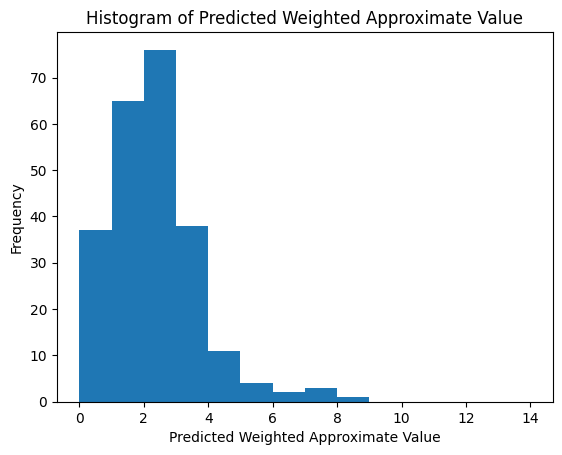

In [ ]:
plt.hist(preds, bins = bins)
plt.ylabel('Frequency')
plt.xlabel('Predicted Weighted Approximate Value')
plt.title('Histogram of Predicted Weighted Approximate Value')
plt.show()

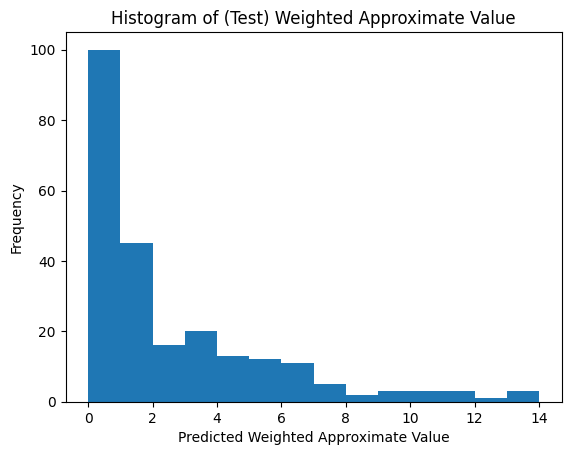

In [ ]:
plt.hist(test_y, bins = bins)
plt.ylabel('Frequency')
plt.xlabel('Predicted Weighted Approximate Value')
plt.title('Histogram of (Test) Weighted Approximate Value')
plt.show()

In [ ]:
! pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 4.5 MB/s eta 0:00:00


In [ ]:
! pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 2.0 MB/s eta 0:00:00


In [ ]:
import skopt
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.model_selection import KFold
from sklearn.metrics import make_scorer, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import numpy as np



kf = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)
# ── 1. Random Forest ──────────────────────────────────────────────────────────

X_encoded = X_nona.copy()
#for col in X_encoded.select_dtypes(include='object').columns:
    #X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col].astype(str))

preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
preprocessor_fold.set_output(transform="pandas")

X_encoded = preprocessor_fold.fit_transform(X_nona)

from sklearn.ensemble import RandomForestRegressor

rf_search = BayesSearchCV(
    RandomForestRegressor(random_state=42),
    search_spaces={
        'n_estimators':     Integer(100, 1000),
        'max_depth':        Integer(3, 20),
        'min_samples_split': Integer(2, 50),
        'min_samples_leaf': Integer(1, 250),
        'max_features':     Real(0.4,1),
    },
    n_iter=20,           # number of Bayesian iterations
    cv=kf,
    scoring=rmse_scorer,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_encoded, y_nona)
print("Best RF params:", rf_search.best_params_)
print(f"Best RF CV RMSE: {-rf_search.best_score_:.4f}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [ ]:
X_encoded = X_nona.copy()

preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
preprocessor_fold.set_output(transform="pandas")

X_encoded = preprocessor_fold.fit_transform(X_encoded)

xgb_search = BayesSearchCV(
    XGBRegressor(tree_method='hist',
                 random_state=42,
                 objective = 'reg:tweedie',
                 eval_metric = 'rmse'),
    search_spaces={
        'n_estimators':   Integer(100, 10000),
        'max_depth':      Integer(3, 10),
        'learning_rate':  Real(0.001, 0.1, prior='log-uniform'),
        'subsample':      Real(0.5, 1.0),
        'colsample_bytree': Real(0.5, 1.0),
        #'reg_alpha':      Real(1e-3, 50.0, prior='log-uniform'),
        'reg_lambda':     Real(1e-3, 50.0, prior='log-uniform'),
    },
    n_iter=20,
    cv=kf,
    scoring=rmse_scorer,   # already fixed from section 1
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_search.fit(X_encoded, y_nona)  # use X_encoded, not X_nona
print("Best XGB params:", xgb_search.best_params_)
print(f"Best XGB CV RMSE: {-xgb_search.best_score_:.4f}")

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [ ]:
from catboost import CatBoostRegressor
import optuna
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import cross_val_score

X_encoded = X_nona.copy()

preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original),
            #('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
preprocessor_fold.set_output(transform="pandas")

X_encoded = preprocessor_fold.fit_transform(X_encoded)

cat_features_list = [X_encoded.columns.get_loc(col) for col in X_encoded.select_dtypes(include='object').columns]

def catboost_objective(trial):
    params = {
        'iterations':    trial.suggest_int('iterations',100, 2000),
        'depth':         trial.suggest_int('depth', 2, 5),
        'learning_rate': trial.suggest_float('eta', 0.001, 0.05, log = True),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 5.0, 20.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'loss_function': GammaObjective(),
        'eval_metric':   GammaRMSEMetric(),
        'min_child_samples' : trial.suggest_int('min_child_samples', 1, 20),
        'verbose':       0,
        'random_state' : 42
    }
    scores = []
    for train_idx, val_idx in kf.split(X_encoded):  # X_nona is fine here, CatBoost handles strings
        X_tr, X_val = X_encoded.iloc[train_idx], X_encoded.iloc[val_idx]
        y_tr, y_val = y_nona.iloc[train_idx], y_nona.iloc[val_idx]
        m = CatBoostRegressor(**params)
        m.fit(X_tr, y_tr + 1, cat_features=cat_features_list, verbose=0)
        preds = np.exp(m.predict(X_val)) - 1
        scores.append(root_mean_squared_error(y_val, preds))
    return np.mean(scores)

study = optuna.create_study(direction='minimize')
study.optimize(catboost_objective, n_trials=30, show_progress_bar=True)
print("Best CatBoost params:", study.best_params)
print(f"Best CatBoost CV RMSE: {study.best_value:.4f}")

[I 2026-04-20 20:05:49,932] A new study created in memory with name: no-name-339acb2b-6c8f-424c-821a-02665ac6b3fe


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-20 20:06:06,966] Trial 0 finished with value: 2.6689091079412024 and parameters: {'iterations': 730, 'depth': 5, 'eta': 0.03210194093621402, 'l2_leaf_reg': 12.433657003708582, 'bagging_temperature': 0.3355575726619551, 'min_child_samples': 17}. Best is trial 0 with value: 2.6689091079412024.
[I 2026-04-20 20:06:10,464] Trial 1 finished with value: 2.785687519832061 and parameters: {'iterations': 238, 'depth': 2, 'eta': 0.016720960898013455, 'l2_leaf_reg': 11.682618132042327, 'bagging_temperature': 0.482752407797734, 'min_child_samples': 9}. Best is trial 0 with value: 2.6689091079412024.
[I 2026-04-20 20:06:22,168] Trial 2 finished with value: 2.6482210229454166 and parameters: {'iterations': 1523, 'depth': 2, 'eta': 0.009167212473302606, 'l2_leaf_reg': 7.4928259865150935, 'bagging_temperature': 0.9480444788154581, 'min_child_samples': 6}. Best is trial 2 with value: 2.6482210229454166.
[I 2026-04-20 20:06:55,602] Trial 3 finished with value: 2.667425991157651 and parameters

In [ ]:
X_encoded = X_nona.copy()

preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
preprocessor_fold.set_output(transform="pandas")

X_encoded = preprocessor_fold.fit_transform(X_encoded)

def ngboost_objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators',100, 2000),
        'Base':  DecisionTreeRegressor(
            max_depth = trial.suggest_int('depth', 2, 5),
            max_features = trial.suggest_float('max_features', 0.4, 1),
            min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
            ),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.1, log = True),
        'Dist': LogNormal,
        'minibatch_frac': trial.suggest_float('minibatch_frac', 0.5, 1.0),
        'verbose':       0,
        'random_state' : 42
    }


    scores = []
    for train_idx, val_idx in kf.split(X_encoded):
        X_tr, X_val = X_encoded.iloc[train_idx], X_encoded.iloc[val_idx]
        y_tr, y_val = y_nona.iloc[train_idx], y_nona.iloc[val_idx]
        m = NGBRegressor(
      **params
    )
        m.fit(X_tr, y_tr + 1,
              X_val = X_val,
              Y_val = (y_val + 1))
        preds = m.predict(X_val) - 1
        scores.append(root_mean_squared_error(y_val, preds))
    return np.mean(scores)

study_ngboost = optuna.create_study(direction='minimize')
study_ngboost.optimize(ngboost_objective, n_trials=30, show_progress_bar=True)
print("Best NGBoost params:", study_ngboost.best_params)
print(f"Best NGBoost CV RMSE: {study_ngboost.best_value:.4f}")

[I 2026-04-20 18:10:11,021] A new study created in memory with name: no-name-7a6944dc-5465-47b2-86cd-53b40d83be2f


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-20 18:11:38,765] Trial 0 finished with value: 2.6672721850412904 and parameters: {'n_estimators': 623, 'depth': 5, 'max_features': 0.7871276688354273, 'min_samples_split': 12, 'learning_rate': 0.00984584982097912, 'minibatch_frac': 0.9813575716676726}. Best is trial 0 with value: 2.6672721850412904.
[I 2026-04-20 18:12:45,632] Trial 1 finished with value: 2.6100491839047164 and parameters: {'n_estimators': 686, 'depth': 3, 'max_features': 0.6286573324836051, 'min_samples_split': 8, 'learning_rate': 0.0059982846857276504, 'minibatch_frac': 0.5475098553334564}. Best is trial 1 with value: 2.6100491839047164.
[I 2026-04-20 18:14:23,528] Trial 2 finished with value: 2.771546190185104 and parameters: {'n_estimators': 977, 'depth': 5, 'max_features': 0.5329739108899553, 'min_samples_split': 9, 'learning_rate': 0.07439650340547264, 'minibatch_frac': 0.6729054827629665}. Best is trial 1 with value: 2.6100491839047164.
[I 2026-04-20 18:16:33,155] Trial 3 finished with value: 2.639270

In [ ]:
# 1. Random Forest
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_nona, test_size=0.4, random_state=42)

best_rf = RandomForestRegressor(**rf_search.best_params_, random_state=42)
best_rf.fit(X_train, y_train)
rf_preds = best_rf.predict(X_test)
print(f"RF Test RMSE: {root_mean_squared_error(y_test, rf_preds):.4f}")

# 2. XGBoost
best_xgb = XGBRegressor(**xgb_search.best_params_, tree_method='hist', random_state=42)
best_xgb.fit(X_train, y_train)
xgb_preds = best_xgb.predict(X_test)
print(f"XGB Test RMSE: {root_mean_squared_error(y_test, xgb_preds):.4f}")

# 3. NGBoost
params = {
        'n_estimators':    300,
        'Base':         DecisionTreeRegressor(
            max_depth = study_ngboost.best_params['depth'],
            max_features = study_ngboost.best_params['max_features'],
            min_samples_split = study_ngboost.best_params['min_samples_split']
            ),
        'learning_rate': 0.01,
        'Dist': LogNormal,
        'minibatch_frac': study_ngboost.best_params['minibatch_frac'],
        'verbose':       0,
        'random_state' : 42
    }
best_ngb = NGBRegressor(**params)

best_ngb.fit(X_train, y_train + 1)

ng_preds = best_ngb.predict(X_test) - 1

print(f"NGBoost Test RMSE: {root_mean_squared_error(y_test, ng_preds):.4f}")


# 4. CatBoost
best_cb = CatBoostRegressor(
    # iterations=study.best_params['iterations'],
    # depth=study.best_params['depth'],
    # learning_rate=study.best_params['learning_rate'],
    # l2_leaf_reg=study.best_params['l2_leaf_reg'],
    # bagging_temperature=study.best_params['bagging_temperature'],
    **study.best_params,
    loss_function=GammaObjective(),
    eval_metric=GammaRMSEMetric(),
    verbose=0
)

X_encoded = X_nona.copy()

preprocessor_fold = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols_original),
        ],
    )
preprocessor_fold.set_output(transform="pandas")

X_encoded = preprocessor_fold.fit_transform(X_encoded)

cat_features_list = [X_encoded.columns.get_loc(col) for col in X_encoded.select_dtypes(include='object').columns]

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_nona, test_size=0.4, random_state=42)


best_cb.fit(X_train, y_train + 1, cat_features=cat_features_list)
cb_preds = np.exp(best_cb.predict(X_test)) - 1
print(f"CatBoost Test RMSE: {root_mean_squared_error(y_test, cb_preds):.4f}")

# ── Compare All Three ─────────────────────────────────────────────────────────
print("\n── Model Comparison ──")
print(f"Random Forest RMSE: {root_mean_squared_error(y_test, rf_preds):.4f}")
print(f"XGBoost RMSE:       {root_mean_squared_error(y_test, xgb_preds):.4f}")
print(f"NGBoost Test RMSE: {root_mean_squared_error(y_test, ng_preds):.4f}")
print(f"CatBoost RMSE:      {root_mean_squared_error(y_test, cb_preds):.4f}")

RF Test RMSE: 2.7288
XGB Test RMSE: 2.7801
NGBoost Test RMSE: 2.6910
CatBoost Test RMSE: 2.6591

── Model Comparison ──
Random Forest RMSE: 2.7288
XGBoost RMSE:       2.7801
CatBoost RMSE:      2.6591


## **With PCA**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pprint import pprint
import pandas as pd

pd.set_option('display.max_columns', None)

merged = pd.read_csv('merged.csv', index_col = 0)
merged.head()

numeric_df = merged.select_dtypes(include='number')

drop_columns = ['player_id', 'season_x', 'college_id', 'nfl_team_id',
                'year', 'round_x', 'pick_number', 'overall', 'height_in', 'weight_lbs',
                'season_y', 'round_y', 'pick', 'w_av', 'car_av', 'dr_av', 'wt', 'rookie_season',
                'last_season', 'birth_year']

# dropping unnecessary columns
numeric_df = numeric_df.drop(columns=drop_columns)

numeric_df.fillna(value={
    'fumbles_FUM' : 0,
    'fumbles_LOST' : 0,
    'fumbles_REC' : 0,
    'passing_ATT': 0,
    'passing_COMPLETIONS' : 0,
    'passing_PCT' : 0,
    'passing_INT' : 0,
    'passing_TD' : 0,
    'passing_YDS' : 0,
    'passing_YPA' : 0,
    'receiving_LONG' : 0,
    'receiving_REC' : 0,
    'receiving_TD' : 0,
    'receiving_YDS' : 0,
    'receiving_YPR' : 0,
    'rushing_ATT' : 0,
    'rushing_LONG' : 0,
    'rushing_TD' : 0,
    'rushing_YDS' : 0,
    'rushing_YPC' : 0,
    'avg_ppa_rush' : 0
},
              inplace=True)

# dropping columns with more than 50% of the data missing
numeric_df = numeric_df.loc[:,
                            numeric_df.isnull().\
                            mean() < 0.5]
# Adding INT%
numeric_df['INT_pct'] = numeric_df['passing_INT']/numeric_df['passing_ATT']

numeric_df.fillna(value={'INT_pct' : 0}, inplace=True)

print("numeric_df Shape:", numeric_df.shape)
print("numeric_df Columns: ")
pprint(list(numeric_df.columns))

numeric_df Shape: (12408, 45)
numeric_df Columns: 
['usage_passing_downs',
 'usage_standard_downs',
 'usage_third_down',
 'usage_second_down',
 'usage_first_down',
 'usage_rush',
 'usage_var_pass',
 'usage_overall',
 'avg_ppa_passing_downs',
 'avg_ppa_standard_downs',
 'avg_ppa_third_down',
 'avg_ppa_second_down',
 'avg_ppa_first_down',
 'avg_ppa_rush',
 'avg_ppa_var_pass',
 'avg_ppa_all',
 'total_ppa_passing_downs',
 'total_ppa_standard_downs',
 'total_ppa_third_down',
 'total_ppa_second_down',
 'total_ppa_first_down',
 'total_ppa_rush',
 'total_ppa_var_pass',
 'total_ppa_all',
 'fumbles_FUM',
 'fumbles_LOST',
 'fumbles_REC',
 'passing_ATT',
 'passing_COMPLETIONS',
 'passing_INT',
 'passing_PCT',
 'passing_TD',
 'passing_YDS',
 'passing_YPA',
 'receiving_LONG',
 'receiving_REC',
 'receiving_TD',
 'receiving_YDS',
 'receiving_YPR',
 'rushing_ATT',
 'rushing_LONG',
 'rushing_TD',
 'rushing_YDS',
 'rushing_YPC',
 'INT_pct']


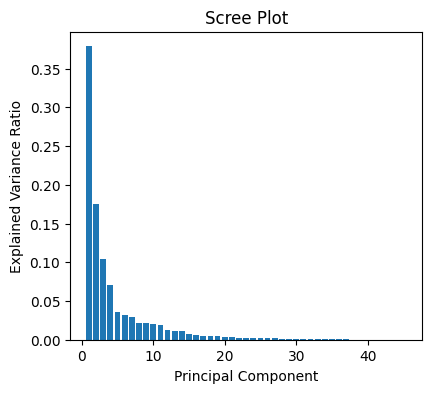

In [ ]:
from sklearn.impute import KNNImputer
#redoing the analysis but using the imputer strategy, still removing columns with too many NAs

numeric_df_nn = numeric_df.copy()

imputer = KNNImputer()
X_imputed = imputer.fit_transform(numeric_df_nn)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

pca = PCA()
pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained)+1), explained)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot')
plt.show()


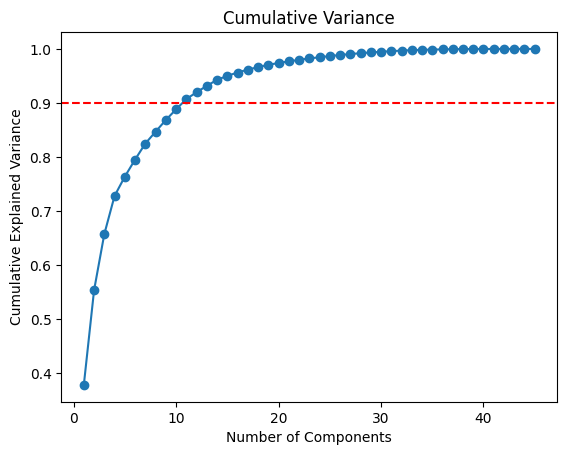

In [ ]:
plt.plot(range(1, len(cumulative)+1), cumulative, marker='o')
plt.axhline(0.90, color='r', linestyle='--', label='90% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Variance')
plt.show()

Number of Components:  11


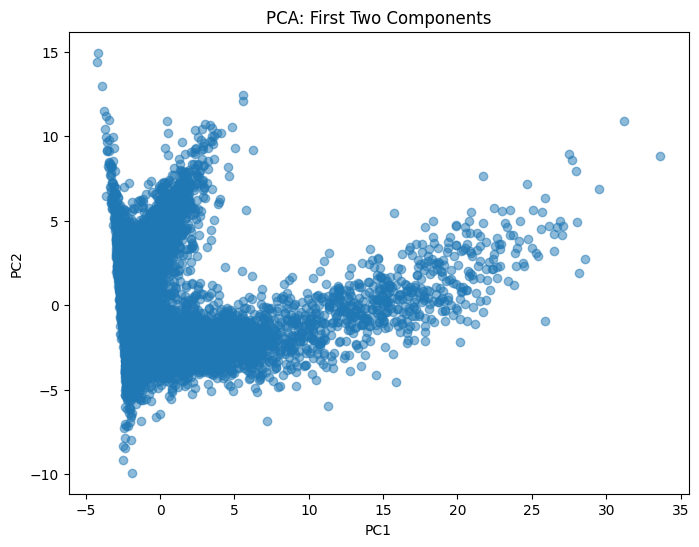

In [ ]:
n_components_90 = np.argmax(cumulative >= 0.90) + 1
print("Number of Components: ", n_components_90)
pca_final = PCA(n_components=n_components_90)
X_pca = pca_final.fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: First Two Components')
plt.show()

In [ ]:
pd.DataFrame(X_pca).head()

,0,1,2,3,4,5,6,7,8,9,10
0,0.013674,4.885381,0.598004,-2.902589,0.151843,-0.503605,0.500284,-0.275219,0.228762,-0.492442,0.087464
1,16.477519,1.253542,-5.803526,-0.065275,5.481129,3.650532,-1.254370,3.377177,5.295272,-0.065293,0.069200
2,-1.076598,-2.698908,0.517444,0.046967,-0.819433,0.670059,0.142213,-0.209897,0.072852,-0.571026,0.045988
3,-1.789299,-1.976706,0.048706,0.053245,-0.787761,1.069993,0.713573,-0.353871,0.195415,-0.229803,0.111052
4,-1.026361,-1.600486,-0.376665,-0.072417,-1.194921,1.468472,0.636271,-0.186199,0.043053,-0.221087,-0.074797


In [ ]:
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
display(pca_df.head())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
0,0.013674,4.885381,0.598004,-2.902589,0.151843,-0.503605,0.500284,-0.275219,0.228762,-0.492442,0.087464
1,16.477519,1.253542,-5.803526,-0.065275,5.481129,3.650532,-1.254370,3.377177,5.295272,-0.065293,0.069200
2,-1.076598,-2.698908,0.517444,0.046967,-0.819433,0.670059,0.142213,-0.209897,0.072852,-0.571026,0.045988
3,-1.789299,-1.976706,0.048706,0.053245,-0.787761,1.069993,0.713573,-0.353871,0.195415,-0.229803,0.111052
4,-1.026361,-1.600486,-0.376665,-0.072417,-1.194921,1.468472,0.636271,-0.186199,0.043053,-0.221087,-0.074797


In [ ]:
display(pca_df.describe())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11
count,1.240800e+04,1.240800e+04,1.240800e+04,1.240800e+04,1.240800e+04,12408.000000,1.240800e+04,1.240800e+04,1.240800e+04,1.240800e+04,1.240800e+04
mean,-3.664953e-17,-1.649229e-16,2.290596e-17,-6.413668e-17,-2.748715e-17,0.000000,1.832476e-17,2.748715e-17,1.832476e-17,5.153840e-18,-9.735031e-18
std,4.128000e+00,2.806875e+00,2.162707e+00,1.781459e+00,1.266288e+00,1.191282,1.155069e+00,9.923000e-01,9.883082e-01,9.410348e-01,9.252363e-01
min,-4.258547e+00,-9.910852e+00,-9.410381e+00,-1.124061e+01,-1.032369e+01,-8.268304,-9.143892e+00,-3.759426e+00,-9.506912e+00,-8.333659e+00,-1.037020e+01
25%,-2.141407e+00,-2.319095e+00,-9.489644e-01,-8.832755e-01,-4.624272e-01,-0.484819,-5.780689e-01,-3.246132e-01,-2.199306e-01,-4.668021e-01,-6.698728e-02
50%,-1.404994e+00,-3.326165e-01,-4.150880e-01,5.401067e-02,-7.856800e-02,0.007423,-2.842385e-01,-5.461763e-02,-3.046192e-02,1.168475e-02,5.326603e-02
75%,1.697458e-01,1.954164e+00,4.933495e-01,8.823541e-01,1.758837e-01,0.535548,3.161706e-01,1.582876e-01,2.122881e-01,4.782868e-01,1.779165e-01
max,3.364053e+01,1.495094e+01,1.959531e+01,1.300503e+01,1.470234e+01,13.894977,1.017155e+01,1.967492e+01,2.298372e+01,9.790030e+00,1.903814e+01


In [ ]:
# Adding Categorical Variables to PCA
pca_df_catvars = pd.concat([pca_df,
                            merged[[
                                'position_x', 'conference', 'overall'
                                ]]],
                           axis = 1)

In [ ]:
pca_df_catvars

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,position_x,conference,overall
0,0.013674,4.885381,0.598004,-2.902589,0.151843,-0.503605,0.500284,-0.275219,0.228762,-0.492442,0.087464,WR,PAC,NaN
1,16.477519,1.253542,-5.803526,-0.065275,5.481129,3.650532,-1.254370,3.377177,5.295272,-0.065293,0.069200,QB,B1G,NaN
2,-1.076598,-2.698908,0.517444,0.046967,-0.819433,0.670059,0.142213,-0.209897,0.072852,-0.571026,0.045988,RB,B12,NaN
3,-1.789299,-1.976706,0.048706,0.053245,-0.787761,1.069993,0.713573,-0.353871,0.195415,-0.229803,0.111052,RB,MWC,NaN
4,-1.026361,-1.600486,-0.376665,-0.072417,-1.194921,1.468472,0.636271,-0.186199,0.043053,-0.221087,-0.074797,WR,CUSA,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12403,4.309122,-2.671895,8.179432,1.144396,0.891771,-2.152016,-1.191943,-0.103578,0.139391,0.237734,0.294992,RB,INDAA,NaN
12404,-1.583398,-2.490016,0.028041,0.124448,-1.043911,1.243420,0.819318,-0.444348,0.318278,0.188577,0.069935,RB,INDAA,NaN
12405,-1.082293,1.290785,0.173771,-2.672082,0.494409,-0.581294,-0.097737,-0.024597,0.064408,1.447294,-0.096230,WR,MWC,NaN
12406,-0.156285,-2.032852,2.179235,0.286400,2.429714,2.126537,0.075159,-0.508781,-0.396843,0.801491,0.236160,RB,INDAA,NaN


In [ ]:
model_df = pca_df_catvars.copy()

# Converted w_av from a cumulative stat to a rate stat
model_df['adjusted_w_av'] = (merged['w_av']/
 ((merged['last_season'] + 1) - merged['year'])
)


final_model_df = model_df.dropna(axis = 0, subset = 'overall', inplace=False)

# Filling NA values with 0
final_model_df['adjusted_w_av'].fillna(value=0, inplace=True)

final_model_df.drop(columns=['overall'], inplace=True)

display(final_model_df)

/tmp/ipykernel_1067/2270972919.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_model_df['adjusted_w_av'].fillna(value=0, inplace=True)
/tmp/ipykernel_1067/2270972919.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_model_df['adjusted_w_av'].fillna(value=0, inplace=True)
/tmp/ipykernel_1067/2270972919.py:14: SettingWithCopy

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,position_x,conference,adjusted_w_av
10,2.379974,8.098583,1.386765,-5.345478,-0.285504,-0.184576,1.147611,-0.000554,0.071164,-0.101953,-0.229908,WR,B1G,1.500000
13,-1.583769,-3.479316,0.636603,0.082424,-2.095591,2.803296,3.279848,-1.084911,0.912096,-0.503741,0.369604,WR,SEC,0.000000
15,20.604395,4.259288,-4.335285,-1.215230,-5.314010,3.320777,-2.980628,1.956814,-1.574199,-0.123267,-0.468147,QB,B12,1.000000
37,-1.803939,1.170940,-0.459283,-0.474348,0.069978,-0.221031,-0.147549,-0.208489,0.049867,-0.896991,0.061571,TE,PAC,0.000000
45,13.194168,-1.293327,-5.029455,1.435928,0.162481,-4.788747,-0.625806,-2.264654,2.835728,1.424869,2.167181,QB,B1G,1.454545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10096,5.014520,-1.410776,7.777170,-0.749263,2.492464,-1.074341,-0.404444,-0.475878,-0.019920,0.418249,0.022491,RB,ACC,1.000000
10554,5.010514,-1.658717,8.505253,0.867261,-1.315080,-0.339827,-1.555078,1.642714,-1.300035,0.014894,-0.396956,RB,SEC,3.000000
10645,1.251949,8.687466,1.632179,-3.210707,0.037055,-0.507071,0.931837,-0.010758,0.047611,-0.328225,-0.215367,WR,MWC,0.000000
10661,2.899594,6.802972,2.637415,-4.143153,-0.864548,0.396727,2.986181,0.205332,-0.031811,0.078330,-0.998334,TE,MAC,5.000000


In [ ]:
# final_model_df = model_df.dropna(
#     subset = 'adjusted_w_av',
#     axis = 0,
#     inplace = False
#     )

# final_model_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,position_x,conference,overall,adjusted_w_av
10,2.379974,8.098583,1.386765,-5.345478,-0.285504,-0.184576,1.147611,-0.000554,0.071164,-0.101953,-0.229908,WR,B1G,161.0,1.500000
15,20.604395,4.259288,-4.335285,-1.215230,-5.314010,3.320777,-2.980628,1.956814,-1.574199,-0.123267,-0.468147,QB,B12,103.0,1.000000
37,-1.803939,1.170940,-0.459283,-0.474348,0.069978,-0.221031,-0.147549,-0.208489,0.049867,-0.896991,0.061571,TE,PAC,198.0,0.000000
45,13.194168,-1.293327,-5.029455,1.435928,0.162481,-4.788747,-0.625806,-2.264654,2.835728,1.424869,2.167181,QB,B1G,250.0,1.454545
78,0.508395,6.957133,0.886599,-2.919022,0.193588,-0.284975,-0.813846,0.803978,-0.782745,0.736702,-0.627438,TE,ACC,68.0,1.400000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10096,5.014520,-1.410776,7.777170,-0.749263,2.492464,-1.074341,-0.404444,-0.475878,-0.019920,0.418249,0.022491,RB,ACC,236.0,1.000000
10554,5.010514,-1.658717,8.505253,0.867261,-1.315080,-0.339827,-1.555078,1.642714,-1.300035,0.014894,-0.396956,RB,SEC,126.0,3.000000
10645,1.251949,8.687466,1.632179,-3.210707,0.037055,-0.507071,0.931837,-0.010758,0.047611,-0.328225,-0.215367,WR,MWC,133.0,0.000000
10661,2.899594,6.802972,2.637415,-4.143153,-0.864548,0.396727,2.986181,0.205332,-0.031811,0.078330,-0.998334,TE,MAC,67.0,5.000000


In [ ]:
display(final_model_df.describe())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,adjusted_w_av
count,794.000000,794.000000,794.000000,794.000000,794.000000,794.000000,794.000000,794.000000,794.000000,794.000000,794.000000,794.000000
mean,4.378945,2.798522,2.078850,-1.422383,-0.344186,0.182328,-0.000577,0.265301,-0.217151,-0.012669,-0.129569,2.437036
std,6.967044,3.458405,4.161601,2.158999,1.928060,1.797547,1.579501,1.001262,0.973808,0.649809,0.674175,2.946552
min,-2.651767,-4.488543,-9.410381,-10.311425,-10.323691,-4.788747,-5.792903,-3.220100,-5.942102,-2.460553,-5.317480,0.000000
25%,0.024059,-0.140145,0.072504,-2.812999,-0.831103,-0.551585,-0.870177,-0.204045,-0.440196,-0.367011,-0.259368,0.229167
50%,1.675235,3.212624,1.019626,-1.034197,-0.115525,-0.113958,-0.009709,0.055280,-0.046409,0.018700,-0.062931,1.250000
75%,5.378463,5.263901,3.828197,0.308642,0.095107,0.410232,0.674841,0.462913,0.203108,0.376541,0.085971,3.666667
max,33.640528,12.435554,19.595312,3.691025,13.950965,13.894977,9.528299,7.799338,5.310262,2.724873,6.115026,13.875000


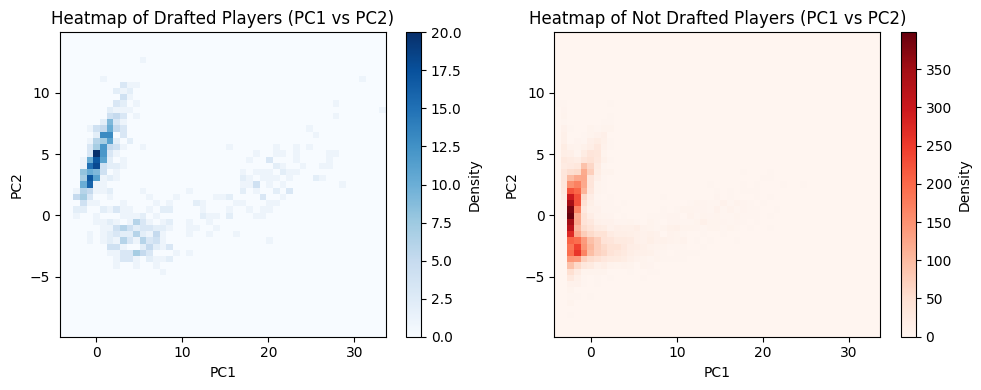

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Create a copy dataframe for plotting to store the 'is_drafted' column
plot_df = model_df.copy()

# Correctly define 'is_drafted' for plot_df
# Given that adjusted_w_av has no NA values in final_model_df (they were dropped),
# the condition 'if value is NA, No' simplifies to 'if value is 0, No'.
# The current logic of '> 0' for Yes and 'else No' correctly covers this.
plot_df['is_drafted'] = np.where(plot_df['adjusted_w_av'].isna(), "No", "Yes")

# Filter data for drafted and not drafted
drafted_df = plot_df[plot_df['is_drafted'] == 'Yes']
not_drafted_df = plot_df[plot_df['is_drafted'] == 'No']

# Define bins for the 2D histogram
bins_x = np.linspace(plot_df['PC1'].min(), plot_df['PC1'].max(), 50)
bins_y = np.linspace(plot_df['PC2'].min(), plot_df['PC2'].max(), 50)

plt.figure(figsize=(10, 4))

# Heatmap for drafted players
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
hist_drafted, x_edges, y_edges = np.histogram2d(drafted_df['PC1'], drafted_df['PC2'], bins=[bins_x, bins_y])
plt.imshow(hist_drafted.T, origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
           cmap='Blues', aspect='auto')
plt.colorbar(label='Density')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Heatmap of Drafted Players (PC1 vs PC2)')

# Heatmap for not drafted players
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
hist_not_drafted, x_edges, y_edges = np.histogram2d(not_drafted_df['PC1'], not_drafted_df['PC2'], bins=[bins_x, bins_y])
plt.imshow(hist_not_drafted.T, origin='lower', extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
           cmap='Reds', aspect='auto')
plt.colorbar(label='Density')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Heatmap of Not Drafted Players (PC1 vs PC2)')

plt.tight_layout()
plt.show()

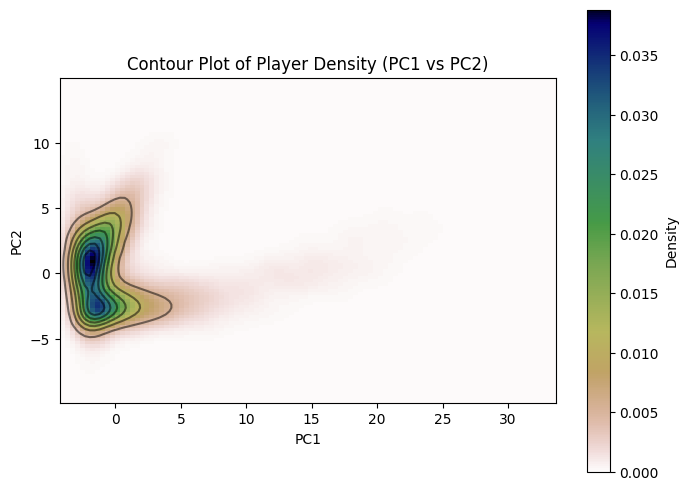

In [ ]:
from scipy.stats import gaussian_kde

# Combine PC1 and PC2 for KDE
x = plot_df['PC1']
y = plot_df['PC2']

# Perform Kernel Density Estimation
kde = gaussian_kde(np.vstack([x, y]))

# Create a grid for the contour plot
x_grid, y_grid = np.mgrid[x.min():x.max():100j, y.min():y.max():100j]
z = kde(np.vstack([x_grid.ravel(), y_grid.ravel()])).reshape(x_grid.shape)

plt.figure(figsize=(8, 6))
plt.imshow(np.rot90(z), cmap=plt.cm.gist_earth_r,
           extent=[x.min(), x.max(), y.min(), y.max()])
plt.colorbar(label='Density')
plt.contour(x_grid, y_grid, z, colors='black', alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Contour Plot of Player Density (PC1 vs PC2)')
plt.show()

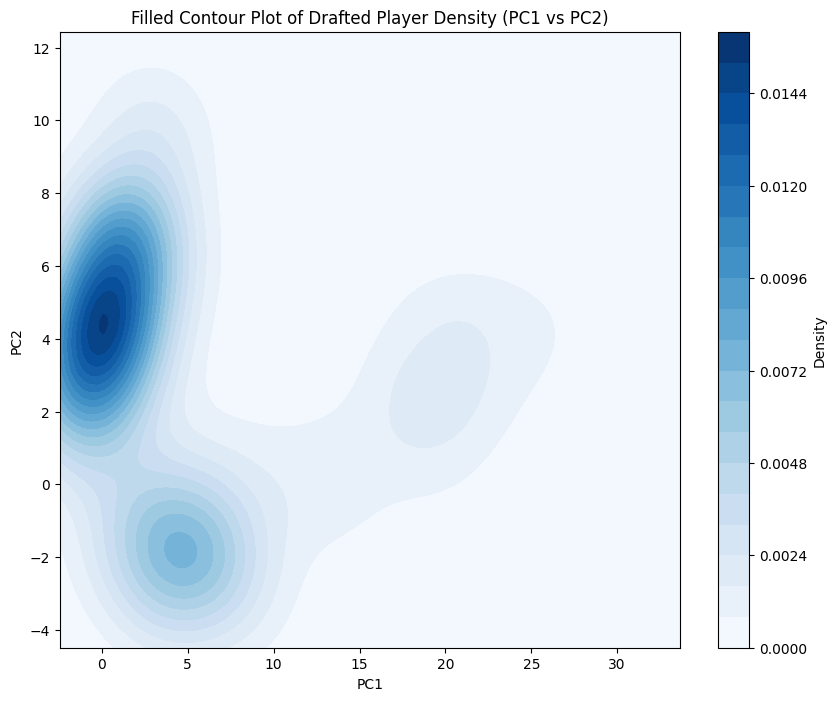

In [ ]:
from scipy.stats import gaussian_kde

# Combine PC1 and PC2 for KDE for drafted players
x_drafted = drafted_df['PC1']
y_drafted = drafted_df['PC2']

# Perform Kernel Density Estimation for drafted players
kde_drafted = gaussian_kde(np.vstack([x_drafted, y_drafted]))

# Create a grid for the contour plot
x_grid, y_grid = np.mgrid[x_drafted.min():x_drafted.max():100j, y_drafted.min():y_drafted.max():100j]
z_drafted = kde_drafted(np.vstack([x_grid.ravel(), y_grid.ravel()])).reshape(x_grid.shape)

plt.figure(figsize=(10, 8))
plt.contourf(x_grid, y_grid, z_drafted, levels=20, cmap='Blues') # Use contourf for filled contours
plt.colorbar(label='Density')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Filled Contour Plot of Drafted Player Density (PC1 vs PC2)')
plt.show()

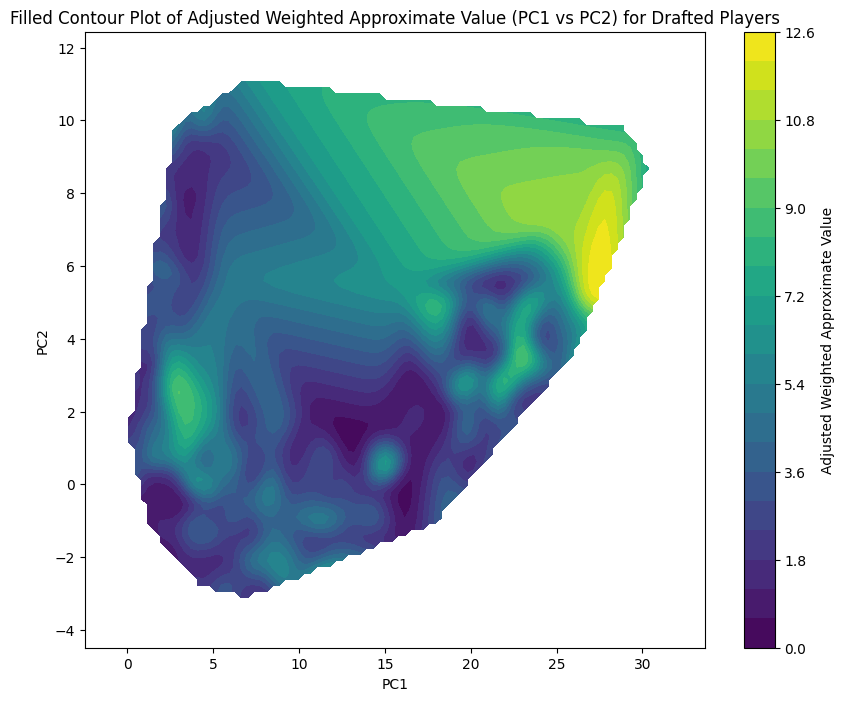

In [ ]:
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

# Combine PC1, PC2, and adjusted_w_av for drafted players
x_drafted = drafted_df['PC1']
y_drafted = drafted_df['PC2']
z_drafted = drafted_df['adjusted_w_av']

# Create a grid for the contour plot
x_grid, y_grid = np.mgrid[x_drafted.min():x_drafted.max():100j, y_drafted.min():y_drafted.max():100j]

# Interpolate adjusted_w_av onto the grid
z_interp = griddata((x_drafted, y_drafted), z_drafted, (x_grid, y_grid), method='linear')
z_smooth = gaussian_filter(z_interp, sigma = 1.5)


plt.figure(figsize=(10, 8))
plt.contourf(x_grid, y_grid, z_smooth, levels=20, cmap='viridis') # Using 'viridis' colormap for 'adjusted_w_av'
plt.colorbar(label='Adjusted Weighted Approximate Value')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Filled Contour Plot of Adjusted Weighted Approximate Value (PC1 vs PC2) for Drafted Players')
plt.show()

In [ ]:
print(final_model_df.head())
print(final_model_df.shape)

          PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
10   2.379974  8.098583  1.386765 -5.345478 -0.285504 -0.184576  1.147611   
13  -1.583769 -3.479316  0.636603  0.082424 -2.095591  2.803296  3.279848   
15  20.604395  4.259288 -4.335285 -1.215230 -5.314010  3.320777 -2.980628   
37  -1.803939  1.170940 -0.459283 -0.474348  0.069978 -0.221031 -0.147549   
45  13.194168 -1.293327 -5.029455  1.435928  0.162481 -4.788747 -0.625806   

         PC8       PC9      PC10      PC11 position_x conference  \
10 -0.000554  0.071164 -0.101953 -0.229908         WR        B1G   
13 -1.084911  0.912096 -0.503741  0.369604         WR        SEC   
15  1.956814 -1.574199 -0.123267 -0.468147         QB        B12   
37 -0.208489  0.049867 -0.896991  0.061571         TE        PAC   
45 -2.264654  2.835728  1.424869  2.167181         QB        B1G   

    adjusted_w_av  
10       1.500000  
13       0.000000  
15       1.000000  
37       0.000000  
45       1.454545  
(794, 14

In [ ]:
X = final_model_df.drop(columns=['adjusted_w_av'], inplace=False)

y = final_model_df['adjusted_w_av']

display(X.head())
display(y.head())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,position_x,conference
10,2.379974,8.098583,1.386765,-5.345478,-0.285504,-0.184576,1.147611,-0.000554,0.071164,-0.101953,-0.229908,WR,B1G
13,-1.583769,-3.479316,0.636603,0.082424,-2.095591,2.803296,3.279848,-1.084911,0.912096,-0.503741,0.369604,WR,SEC
15,20.604395,4.259288,-4.335285,-1.215230,-5.314010,3.320777,-2.980628,1.956814,-1.574199,-0.123267,-0.468147,QB,B12
37,-1.803939,1.170940,-0.459283,-0.474348,0.069978,-0.221031,-0.147549,-0.208489,0.049867,-0.896991,0.061571,TE,PAC
45,13.194168,-1.293327,-5.029455,1.435928,0.162481,-4.788747,-0.625806,-2.264654,2.835728,1.424869,2.167181,QB,B1G


,adjusted_w_av
10,1.500000
13,0.000000
15,1.000000
37,0.000000
45,1.454545


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split


train_x, test_x, train_y, test_y = train_test_split(X,
                                                    y,
                                                    test_size = 0.3,
                                                    random_state = 42)

num_cols = train_x.select_dtypes(include=np.number).columns
cat_cols = train_x.select_dtypes(include=['object']).columns


In [ ]:
from catboost import CatBoostRegressor
import optuna
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import KFold

kf = KFold(n_splits=10, shuffle=True, random_state=101)

X_encoded = X.copy()

### Commented Out Code is not needed for Catboost

# preprocessor_fold = ColumnTransformer(
#         transformers=[
#             ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
#         ],
#     )
# preprocessor_fold.set_output(transform="pandas")

# X_encoded = preprocessor_fold.fit_transform(X_encoded)

cat_features_list = [X_encoded.columns.get_loc(col) for col in X_encoded.select_dtypes(include='object').columns]

def catboost_objective(trial):
    params = {
        'iterations':    trial.suggest_int('iterations',100, 2000),
        'depth':         trial.suggest_int('depth', 2, 5),
        'learning_rate': trial.suggest_float('eta', 0.001, 0.05, log = True),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 5.0, 20.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'loss_function': GammaObjective(),
        'eval_metric':   GammaRMSEMetric(),
        'min_child_samples' : trial.suggest_int('min_child_samples', 1, 20),
        'verbose':       0,
        'random_state' : 42
    }
    scores = []
    for train_idx, val_idx in kf.split(X_encoded):  # X_nona is fine here, CatBoost handles strings
        X_tr, X_val = X_encoded.iloc[train_idx], X_encoded.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        m = CatBoostRegressor(**params)
        m.fit(X_tr, y_tr + 1, cat_features=cat_features_list, verbose=0)
        preds = np.exp(m.predict(X_val)) - 1
        scores.append(root_mean_squared_error(y_val, preds))
    return np.mean(scores)

study = optuna.create_study(direction='minimize')
study.optimize(catboost_objective, n_trials=30, show_progress_bar=True)
print("Best CatBoost params:", study.best_params)
print(f"Best CatBoost CV RMSE: {study.best_value:.4f}")

[I 2026-04-22 16:00:58,377] A new study created in memory with name: no-name-86644bac-b5f3-41bb-b266-154026dd38cf


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-22 16:01:23,347] Trial 0 finished with value: 3.070693074303777 and parameters: {'iterations': 1017, 'depth': 2, 'eta': 0.0017610832950133639, 'l2_leaf_reg': 9.963325348922979, 'bagging_temperature': 0.2865317592217854, 'min_child_samples': 14}. Best is trial 0 with value: 3.070693074303777.
[I 2026-04-22 16:02:15,978] Trial 1 finished with value: 3.108610692827583 and parameters: {'iterations': 1269, 'depth': 5, 'eta': 0.0013745504189379765, 'l2_leaf_reg': 14.147000037239714, 'bagging_temperature': 0.5082686431614933, 'min_child_samples': 16}. Best is trial 0 with value: 3.070693074303777.
[I 2026-04-22 16:02:27,461] Trial 2 finished with value: 3.0721145603766074 and parameters: {'iterations': 324, 'depth': 2, 'eta': 0.005610170884130924, 'l2_leaf_reg': 17.232298856135372, 'bagging_temperature': 0.5053913479435306, 'min_child_samples': 18}. Best is trial 0 with value: 3.070693074303777.
[I 2026-04-22 16:02:51,257] Trial 3 finished with value: 2.6798241358960913 and paramet

In [ ]:
%%capture
! pip install ngboost

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from ngboost import NGBRegressor
from ngboost.distns import LogNormal
X_encoded = X.copy()

preprocessor_fold = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols) # Apply OneHotEncoder to categorical columns
        ],
    )
preprocessor_fold.set_output(transform="pandas")

X_encoded = preprocessor_fold.fit_transform(X_encoded)

def ngboost_objective(trial):
    params = {
        'n_estimators':    trial.suggest_int('n_estimators',100, 2000),
        'Base':  DecisionTreeRegressor(
            max_depth = trial.suggest_int('depth', 2, 5),
            max_features = trial.suggest_float('max_features', 0.4, 1),
            min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
            ),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 0.05, log = True),
        'Dist': LogNormal,
        'minibatch_frac': trial.suggest_float('minibatch_frac', 0.5, 1.0),
        'verbose':       0,
        'random_state' : 42
    }


    scores = []
    for train_idx, val_idx in kf.split(X_encoded):
        X_tr, X_val = X_encoded.iloc[train_idx], X_encoded.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        m = NGBRegressor(
      **params
    )
        m.fit(X_tr, y_tr + 1,
              X_val = X_val,
              Y_val = (y_val + 1))
        preds = m.predict(X_val) - 1
        scores.append(root_mean_squared_error(y_val, preds))
    return np.mean(scores)

study_ngboost = optuna.create_study(direction='minimize')
study_ngboost.optimize(ngboost_objective, n_trials=30, show_progress_bar=True)
print("Best NGBoost params:", study_ngboost.best_params)
print(f"Best NGBoost CV RMSE: {study_ngboost.best_value:.4f}")

[I 2026-04-22 16:16:12,687] A new study created in memory with name: no-name-a0751f45-817b-4209-bd64-a6560d2665c4


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-22 16:18:42,774] Trial 0 finished with value: 2.959197848832578 and parameters: {'n_estimators': 796, 'depth': 3, 'max_features': 0.4833558767423566, 'min_samples_split': 4, 'learning_rate': 0.01816144340557658, 'minibatch_frac': 0.7580608860872582}. Best is trial 0 with value: 2.959197848832578.
[I 2026-04-22 16:20:38,896] Trial 1 finished with value: 2.911043575697301 and parameters: {'n_estimators': 706, 'depth': 2, 'max_features': 0.9607581018567721, 'min_samples_split': 5, 'learning_rate': 0.0024298646922951573, 'minibatch_frac': 0.824547486324261}. Best is trial 1 with value: 2.911043575697301.
[I 2026-04-22 16:23:11,031] Trial 2 finished with value: 2.92262762065511 and parameters: {'n_estimators': 952, 'depth': 3, 'max_features': 0.4176561670041244, 'min_samples_split': 15, 'learning_rate': 0.004611844682525408, 'minibatch_frac': 0.8450378706578301}. Best is trial 1 with value: 2.911043575697301.
[I 2026-04-22 16:27:40,734] Trial 3 finished with value: 2.943752871743

In [ ]:
import skopt
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from sklearn.model_selection import KFold
from sklearn.metrics import make_scorer, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import numpy as np

rmse_scorer = make_scorer(root_mean_squared_error, greater_is_better=False)
# ── 1. Random Forest ──────────────────────────────────────────────────────────

X_encoded = X.copy()
#for col in X_encoded.select_dtypes(include='object').columns:
    #X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col].astype(str))

preprocessor_fold = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
preprocessor_fold.set_output(transform="pandas")

X_encoded = preprocessor_fold.fit_transform(X_encoded)

from sklearn.ensemble import RandomForestRegressor

rf_search = BayesSearchCV(
    RandomForestRegressor(random_state=42),
    search_spaces={
        'n_estimators':     Integer(100, 1000),
        'max_depth':        Integer(3, 20),
        'min_samples_split': Integer(2, 50),
        'min_samples_leaf': Integer(1, 250),
        'max_features':     Real(0.4,1),
    },
    n_iter=20,           # number of Bayesian iterations
    cv=kf,
    scoring=rmse_scorer,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

rf_search.fit(X_encoded, y)
print("Best RF params:", rf_search.best_params_)
print(f"Best RF CV RMSE: {-rf_search.best_score_:.4f}")

In [ ]:
X_encoded = X.copy()

preprocessor_fold = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
preprocessor_fold.set_output(transform="pandas")

X_encoded = preprocessor_fold.fit_transform(X_encoded)

xgb_search = BayesSearchCV(
    XGBRegressor(tree_method='hist',
                 random_state=42,
                 objective = 'reg:tweedie',
                 eval_metric = 'rmse'),
    search_spaces={
        'n_estimators':   Integer(100, 10000),
        'max_depth':      Integer(3, 10),
        'learning_rate':  Real(0.001, 0.1, prior='log-uniform'),
        'subsample':      Real(0.5, 1.0),
        'colsample_bytree': Real(0.5, 1.0),
        #'reg_alpha':      Real(1e-3, 50.0, prior='log-uniform'),
        'reg_lambda':     Real(1e-3, 50.0, prior='log-uniform'),
    },
    n_iter=20,
    cv=kf,
    scoring=rmse_scorer,   # already fixed from section 1
    n_jobs=-1,
    random_state=42,
    verbose=1
)

xgb_search.fit(X_encoded, y)  # use X_encoded, not X_nona
print("Best XGB params:", xgb_search.best_params_)
print(f"Best XGB CV RMSE: {-xgb_search.best_score_:.4f}")

In [ ]:
preprocessor_fold = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_original) # Apply OneHotEncoder to categorical columns
        ],
    )
preprocessor_fold.set_output(transform="pandas")

train_x_encoded = preprocessor_fold.fit_transform(train_x)

test_x_encoded = preprocessor_fold.transform(test_x)


best_rf = RandomForestRegressor(**rf_search.best_params_, random_state=42)
best_rf.fit(train_x_encoded, train_y)
rf_preds = best_rf.predict(test_x_encoded)
print(f"RF Test RMSE: {root_mean_squared_error(test_y, rf_preds):.4f}")

# 2. XGBoost
best_xgb = XGBRegressor(**xgb_search.best_params_, tree_method='hist', random_state=42)
best_xgb.fit(train_x_encoded, train_y)
xgb_preds = best_xgb.predict(test_x_encoded)
print(f"XGB Test RMSE: {root_mean_squared_error(test_y, xgb_preds):.4f}")

# 3. NGBoost
params = {
        'n_estimators':    300,
        'Base':         DecisionTreeRegressor(
            max_depth = study_ngboost.best_params['depth'],
            max_features = study_ngboost.best_params['max_features'],
            min_samples_split = study_ngboost.best_params['min_samples_split']
            ),
        'learning_rate': 0.01,
        'Dist': LogNormal,
        'minibatch_frac': study_ngboost.best_params['minibatch_frac'],
        'verbose':       0,
        'random_state' : 42
    }
best_ngb = NGBRegressor(**params)

best_ngb.fit(train_x_encoded, train_y + 1)

ng_preds = best_ngb.predict(test_x_ecnoded) - 1

print(f"NGBoost Test RMSE: {root_mean_squared_error(test_y, ng_preds):.4f}")


# 4. CatBoost
best_cb = CatBoostRegressor(
    # iterations=study.best_params['iterations'],
    # depth=study.best_params['depth'],
    # learning_rate=study.best_params['learning_rate'],
    # l2_leaf_reg=study.best_params['l2_leaf_reg'],
    # bagging_temperature=study.best_params['bagging_temperature'],
    **study.best_params,
    loss_function=GammaObjective(),
    eval_metric=GammaRMSEMetric(),
    verbose=0
)


best_cb.fit(train_x, train_y + 1, cat_features=cat_features_list)
cb_preds = np.exp(best_cb.predict(test_x)) - 1
print(f"CatBoost Test RMSE: {root_mean_squared_error(y_test, cb_preds):.4f}")

# ── Compare All Three ─────────────────────────────────────────────────────────
print("\n── Model Comparison ──")
print(f"Random Forest RMSE: {root_mean_squared_error(y_test, rf_preds):.4f}")
print(f"XGBoost RMSE:       {root_mean_squared_error(y_test, xgb_preds):.4f}")
print(f"NGBoost Test RMSE: {root_mean_squared_error(y_test, ng_preds):.4f}")
print(f"CatBoost RMSE:      {root_mean_squared_error(y_test, cb_preds):.4f}")